# EDA (Exploratory Data Analysis)

### Analyze the Missing Values

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [4]:
train_df = pd.read_csv("../data/application_train.csv")

In [5]:
total_missing = train_df.isnull().sum().sum()

print("Total Missing Values:", total_missing)

Total Missing Values: 9152465


In [ ]:
missing = pd.DataFrame({

    "Missing Count": train_df.isnull().sum(),

    "Missing Percentage":
    train_df.isnull().mean()*100

})

missing = missing.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing.head(30)

In [ ]:
# Top 20 missing values  with percentage 
import matplotlib.pyplot as plt

top_missing = missing.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_missing.index,
    top_missing["Missing Percentage"]
)

plt.xlabel("Missing Percentage")

plt.title("Top 20 Features with Highest Missing Values")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# Here we see the percentages wise missing values high,mediun,low to understand the missing values in dataset 
high_missing = missing[
    missing["Missing Percentage"] > 50
]

medium_missing = missing[
    (missing["Missing Percentage"] > 20)
    &
    (missing["Missing Percentage"] <= 50)
]

low_missing = missing[
    missing["Missing Percentage"] <= 20
]

print("High Missing :", len(high_missing))

print("Medium Missing :", len(medium_missing))

print("Low Missing :", len(low_missing))

In [ ]:
# columns without missing values
no_missing = train_df.columns[
    train_df.isnull().sum()==0
]

print("Columns without Missing Values")

print(no_missing)

In [ ]:
train_df["TARGET"].value_counts()

In [ ]:
target_summary = pd.DataFrame({

    "Count": train_df["TARGET"].value_counts(),

    "Percentage":
    round(train_df["TARGET"].value_counts(normalize=True)*100,2)

})

target_summary

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

train_df["TARGET"].value_counts().plot(
    kind="bar",
    color=["steelblue","tomato"]
)

plt.title("Target Variable Distribution")

plt.xlabel("Target")

plt.ylabel("Number of Customers")

plt.xticks([0,1],["Repaid","Default"])

plt.show()

In [ ]:
plt.figure(figsize=(6,6))

train_df["TARGET"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Repaid","Default"],
    startangle=90
)

plt.ylabel("")

plt.title("Loan Repayment Distribution")

plt.show()

### Numerical feature analysis

In [ ]:
# identifying numerical columns in the dataset
numerical_columns = train_df.select_dtypes(
    include=["int64","float64"]
)

numerical_columns.head()

In [ ]:
print("Number of Numerical Features:",
      numerical_columns.shape[1])

In [ ]:
list(numerical_columns.columns)

In [ ]:
numerical_columns.describe().T

In [ ]:
# Identifying missing values in numerical columns
numerical_missing = numerical_columns.isnull().sum()

numerical_missing = numerical_missing[
    numerical_missing>0
].sort_values(
    ascending=False
)

numerical_missing.head(20)

In [ ]:
# Identifying missing value percentages in numerical columns
(
    numerical_columns
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(20)
)

In [ ]:
# measuring skewness in numerical columns
# how assymetric the distribution of numerical features is, skewness can be positive or negative. A positive skew indicates that the 
# tail on the right side of the distribution is longer or fatter than the left side, while a negative skew indicates that the tail on the
#  left side is longer or fatter than the right side. A skewness value between -0.5 and 0.5 indicates a fairly symmetrical distribution, 
# while values outside this range indicate increasing levels of skewness.
skewness = numerical_columns.skew()

skewness.sort_values(
    ascending=False
).head(20)

In [ ]:
# high kurtosis indicates that the distribution has heavy tails or outliers, while low kurtosis indicates that the distribution is
#  light-tailed or lacks outliers. A normal distribution has a kurtosis of 3, so values greater than 3 indicate a leptokurtic distribution 
# (heavy tails), while values less than 3 indicate a platykurtic distribution (light tails).
kurtosis = numerical_columns.kurtosis()

kurtosis.sort_values(
    ascending=False
).head(20)

In [ ]:
summary = pd.DataFrame({

    "Minimum": numerical_columns.min(),

    "Maximum": numerical_columns.max(),

    "Mean": numerical_columns.mean(),

    "Median": numerical_columns.median()

})

summary.head()

In [ ]:
numerical_summary = pd.DataFrame({

    "Missing %":
    numerical_columns.isnull().mean()*100,

    "Mean":
    numerical_columns.mean(),

    "Median":
    numerical_columns.median(),

    "Std":
    numerical_columns.std(),

    "Skewness":
    numerical_columns.skew()

})

numerical_summary.head(20)

### Categorical Feature Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
cat_cols = train_df.select_dtypes(include=["object"]).columns

print("Total categorical columns:", len(cat_cols))
cat_cols

In [ ]:
list(cat_cols)

In [ ]:
# checking the unique values in categorical columns
categorical_summary = pd.DataFrame({
    "Unique Values": train_df[cat_cols].nunique()
})

categorical_summary.sort_values(by="Unique Values")

In [ ]:
for col in cat_cols:
    print("=" * 60)
    print(col)
    print(train_df[col].value_counts(dropna=False))

In [ ]:
for col in cat_cols:
    print("\n", col)
    print((train_df[col].value_counts(normalize=True) * 100).round(2))

In [ ]:
# Plot top categories
missing_cat = train_df[cat_cols].isnull().sum()

missing_cat = missing_cat[missing_cat > 0]

missing_cat.sort_values(ascending=False)

In [ ]:
for col in cat_cols[:10]:

    plt.figure(figsize=(8,4))

    sns.countplot(
        y=train_df[col],
        order=train_df[col].value_counts().index
    )

    plt.title(col)
    plt.show()

In [ ]:
# Relationship with Target Variable
for col in cat_cols:

    plt.figure(figsize=(10,5))

    sns.countplot(
        x=col,
        hue="TARGET",
        data=train_df
    )

    plt.xticks(rotation=45)

    plt.title(col)

    plt.show()

In [ ]:
# Default Rate by Category (Better than Countplot)
for col in cat_cols:

    default_rate = (
        train_df
        .groupby(col)["TARGET"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10,4))

    default_rate.plot(kind="bar")

    plt.ylabel("Default Rate")

    plt.title(f"Default Rate by {col}")

    plt.show()

In [ ]:
# Detect rare categories in categorical columns
for col in cat_cols:

    rare = train_df[col].value_counts(normalize=True)

    rare = rare[rare < 0.01]

    if len(rare) > 0:

        print("\n", col)

        print(rare)

In [ ]:
# summary table
summary = pd.DataFrame(index=cat_cols)

summary["Unique Values"] = train_df[cat_cols].nunique()

summary["Missing"] = train_df[cat_cols].isnull().sum()

summary["Most Frequent"] = train_df[cat_cols].mode().iloc[0]

summary["Frequency"] = [
    train_df[col].value_counts().iloc[0]
    for col in cat_cols
]

summary

### Univariate Analysis

In [ ]:
# Select only numerical columns
num_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

print("Total Numerical Features:", len(num_cols))
list(num_cols)

In [ ]:
train_df[num_cols].describe().T

In [ ]:
skewness = train_df[num_cols].skew().sort_values(ascending=False)

skewness

In [ ]:
# histogram 
import matplotlib.pyplot as plt

train_df[num_cols].hist(
    figsize=(20,18),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()

plt.show()

In [ ]:
# kdeplot
import seaborn as sns

for col in num_cols[:10]:

    plt.figure(figsize=(8,4))

    sns.kdeplot(train_df[col], fill=True)

    plt.title(col)

    plt.show()

In [ ]:
# boxplot
for col in num_cols[:10]:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=train_df[col])

    plt.title(col)

    plt.show()

In [ ]:
# missing value distribution 
missing = train_df[num_cols].isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Missing Values")

plt.ylabel("Count")

plt.show()

In [ ]:
# unique values
unique_values = train_df[num_cols].nunique()

unique_values.sort_values()

In [ ]:
# check zero values
zero_count = (train_df[num_cols] == 0).sum()

zero_count = zero_count[zero_count > 0]

zero_count.sort_values(ascending=False)

In [ ]:
# distribution summary table
summary = pd.DataFrame(index=num_cols)

summary["Missing"] = train_df[num_cols].isnull().sum()

summary["Mean"] = train_df[num_cols].mean()

summary["Median"] = train_df[num_cols].median()

summary["Std"] = train_df[num_cols].std()

summary["Min"] = train_df[num_cols].min()

summary["Max"] = train_df[num_cols].max()

summary["Skewness"] = train_df[num_cols].skew()

summary["Unique"] = train_df[num_cols].nunique()

summary

In [ ]:
# Analyze the Target Variable
plt.figure(figsize=(6,4))

sns.countplot(data=train_df, x="TARGET")

plt.title("Target Variable Distribution")

plt.xlabel("TARGET (0 = No Default, 1 = Default)")

plt.ylabel("Count")

plt.show()

print(train_df["TARGET"].value_counts())

print("\nPercentage Distribution:\n")

print((train_df["TARGET"].value_counts(normalize=True) * 100).round(2))

In [ ]:
# correlation matrix
# Correlation matrix
corr_matrix = train_df[num_cols].corr()

corr_matrix.head()

In [ ]:
# correlation heatmap
plt.figure(figsize=(18,14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# coeercation matrix with target variable
target_corr = (
    train_df[num_cols]
    .corr()["TARGET"]
    .sort_values(ascending=False)
)

target_corr


In [ ]:
# barplot of correlation with target variable
plt.figure(figsize=(10,8))

target_corr.drop("TARGET").plot(kind="bar")

plt.title("Correlation with TARGET")

plt.ylabel("Correlation")

plt.show()

In [ ]:
#boxplot by target variable
for col in num_cols[:10]:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x="TARGET",
        y=col,
        data=train_df
    )

    plt.title(f"{col} vs TARGET")

    plt.show()

In [ ]:
sns.scatterplot(
    data=train_df,
    x="AMT_INCOME_TOTAL",
    y="AMT_CREDIT",
    hue="TARGET",
    alpha=0.5
)

plt.title("Income vs Credit Amount")

plt.show()

In [ ]:
pair_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "TARGET"
]

sns.pairplot(
    train_df[pair_features],
    hue="TARGET"
)

plt.show()

In [ ]:
# select imp features 
important_features = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

multivariate_df = train_df[important_features]

multivariate_df.head()

In [ ]:
# pairplot of important features
sns.pairplot(
    multivariate_df,
    hue="TARGET",
    diag_kind="hist"
)

plt.show()

In [ ]:
# correlation heatmap of important features
plt.figure(figsize=(10,8))

sns.heatmap(
    multivariate_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Important Features Correlation")

plt.show()

In [ ]:
# pivote table analysis

pivot_income = train_df.pivot_table(
    values="AMT_INCOME_TOTAL",
    index="NAME_EDUCATION_TYPE",
    columns="TARGET",
    aggfunc="mean"
)

pivot_income

In [ ]:
# feature integration 
train_df["CREDIT_INCOME_RATIO"] = (
    train_df["AMT_CREDIT"] /
    train_df["AMT_INCOME_TOTAL"]
)

train_df["ANNUITY_INCOME_RATIO"] = (
    train_df["AMT_ANNUITY"] /
    train_df["AMT_INCOME_TOTAL"]
)

train_df[
    [
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO"
    ]
].head()

In [ ]:
# relationship of new features with target variable
plt.figure(figsize=(8,5))

sns.boxplot(
    x="TARGET",
    y="CREDIT_INCOME_RATIO",
    data=train_df
)

plt.title("Credit Income Ratio vs Target")

plt.show()

In [6]:
# selecting numerical features
num_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

print(f"Total Numerical Features: {len(num_cols)}")

Total Numerical Features: 106


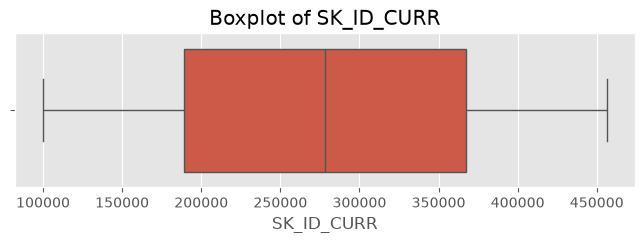

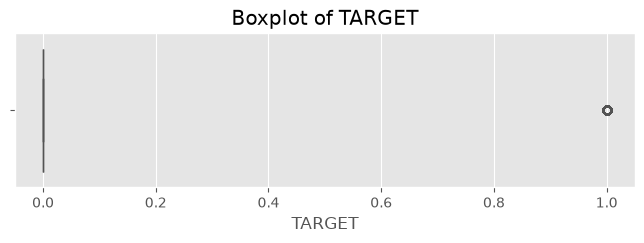

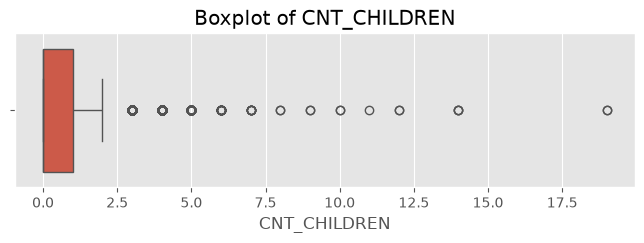

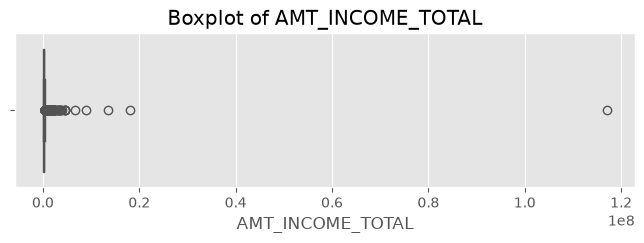

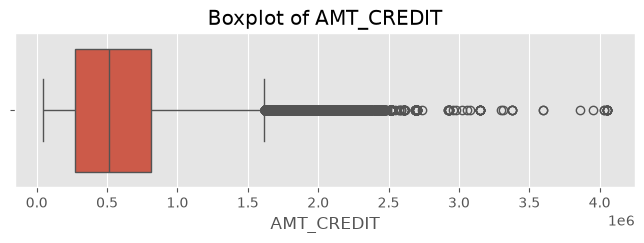

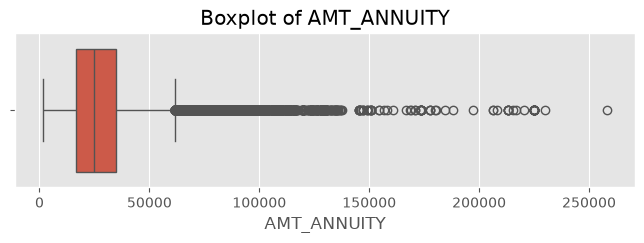

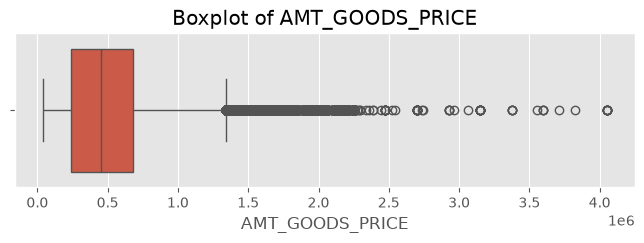

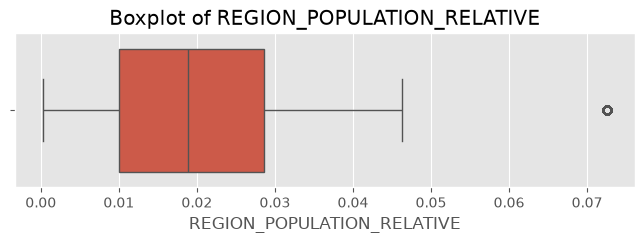

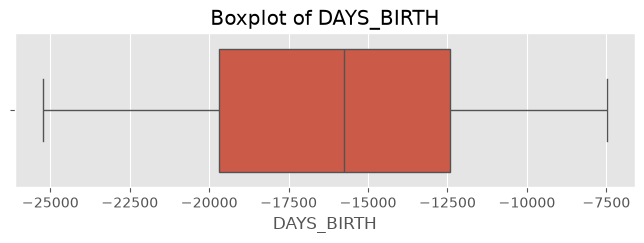

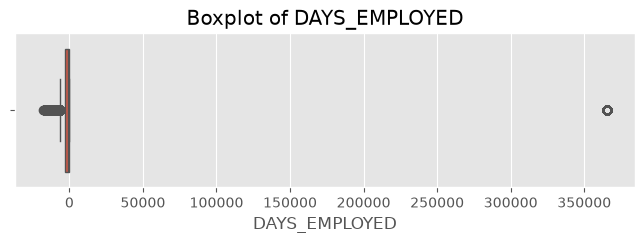

In [7]:
# visualize outlier 
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols[:10]:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=train_df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

In [8]:
# detecting outliers using IQR method
outlier_summary = []

for col in num_cols:

    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train_df[
        (train_df[col] < lower) |
        (train_df[col] > upper)
    ]

    outlier_summary.append({
        "Feature": col,
        "Outliers": len(outliers),
        "Percentage": round(len(outliers) / len(train_df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values("Percentage", ascending=False)

,Feature,Outliers,Percentage
20,REGION_RATING_CLIENT,80527,26.19
21,REGION_RATING_CLIENT_W_CITY,78027,25.37
9,DAYS_EMPLOYED,72217,23.48
27,REG_CITY_NOT_WORK_CITY,70867,23.05
15,FLAG_WORK_PHONE,61308,19.94
...,...,...,...
13,FLAG_MOBIL,1,0.00
88,FLAG_DOCUMENT_10,7,0.00
81,FLAG_DOCUMENT_3,0,0.00
80,FLAG_DOCUMENT_2,13,0.00


In [9]:
# visualize feature with hight outlier
high_outliers = outlier_df[
    outlier_df["Percentage"] > 5
]

high_outliers

,Feature,Outliers,Percentage
1,TARGET,24825,8.07
9,DAYS_EMPLOYED,72217,23.48
14,FLAG_EMP_PHONE,55386,18.01
15,FLAG_WORK_PHONE,61308,19.94
18,FLAG_EMAIL,17442,5.67
20,REGION_RATING_CLIENT,80527,26.19
21,REGION_RATING_CLIENT_W_CITY,78027,25.37
24,REG_REGION_NOT_WORK_REGION,15612,5.08
26,REG_CITY_NOT_LIVE_CITY,24039,7.82
27,REG_CITY_NOT_WORK_CITY,70867,23.05


In [10]:
# detecting outliers using z-score method
from scipy.stats import zscore
import numpy as np

z_scores = np.abs(zscore(train_df[num_cols], nan_policy="omit"))

z_outliers = (z_scores > 3).sum(axis=0)

z_outlier_df = pd.DataFrame({
    "Feature": num_cols,
    "Outliers (Z-score)": z_outliers
})

z_outlier_df.sort_values(
    "Outliers (Z-score)",
    ascending=False
)

,Feature,Outliers (Z-score)
84,FLAG_DOCUMENT_6,27078
86,FLAG_DOCUMENT_8,25024
1,TARGET,24825
26,REG_CITY_NOT_LIVE_CITY,24039
18,FLAG_EMAIL,17442
...,...,...
9,DAYS_EMPLOYED,0
8,DAYS_BIRTH,0
0,SK_ID_CURR,0
21,REGION_RATING_CLIENT_W_CITY,0
